In [1]:
using Plots

In [ ]:
# (** Both left and right walls are reflective **)

# ====================1D Euler Riemann/Piston Solver (Finite Volume)====================

# --------------------Parameters & Grid--------------------
gamma  = 5/3                  # ratio of specific heats
xL = 0
xR = 1.5                  # domain
nx = 2000                  # number of cells
dx = (xR - xL) / nx
xc = (xR + xL) / 2
x  = [xL + (i - 0.5) * dx for i in 1:nx]  # cell centers
CFL  = 0.45              # Courant number
CFLvisc = 0.2
CFLforce = 0.25

tEnd = 0.5                # final time
a00  = 5.0
gg   = 1.0

temp = 1;

Harmonicpotential(xx, tt) = 0.5 * gg * (xx - (xL + 0.1) - 0.5*a00*tt^2)^2
gHarmonicTrap(xx, tt)     = gg * (xx - (xL + 0.1) - 0.5*a00*tt^2)

ReynoldsNumber = 5000;

c0 = Float64(sqrt(gamma*temp))          # N[Sqrt[gamma]]
mach = 1 / c0                  # Mach number
pressureScale = 1.0 / (gamma * mach^2)  # nondimensional pressure-gradient prefactor

InitialDensityProfile(xx)  = exp(-Harmonicpotential(xx, 0)/(pressureScale * temp)) * exp(Harmonicpotential(xL + 0.1, 0)/(pressureScale * temp))
InitialPressureProfile(xx) = temp * exp(-Harmonicpotential(xx, 0)/(pressureScale * temp)) * exp(Harmonicpotential(xL + 0.1, 0)/(pressureScale * temp))

tShock = Float64(2 * c0 / ((gamma + 1) * a00))
a00_tShock = a00 * tShock
xShock = Float64(2 * c0^2 / ((gamma + 1) * a00))


0.24999999999999994

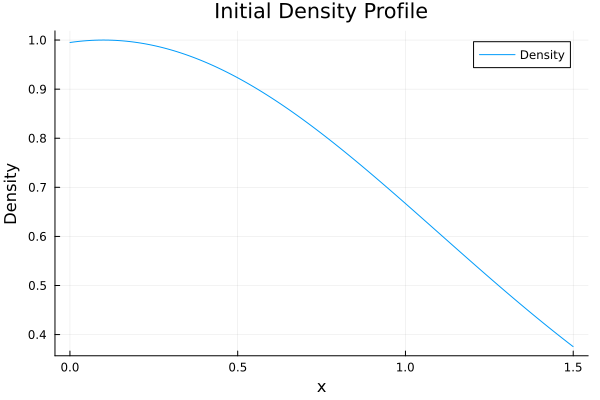

In [3]:
### Plot initial profile of density and pressure
plot(x, [InitialDensityProfile(xx) for xx in x], label="Density", xlabel="x", ylabel="Density", title="Initial Density Profile")

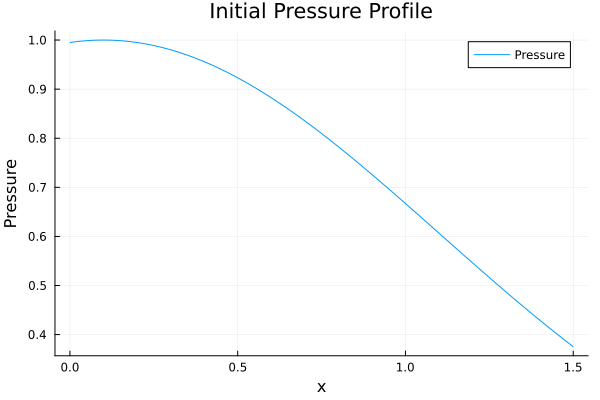

In [4]:
plot(x, [InitialPressureProfile(xx) for xx in x], label="Pressure", xlabel="x", ylabel="Pressure", title="Initial Pressure Profile")

In [5]:
# --------------------Piston-only setup--------------------

# Momentum viscosity (Navier-Stokes-like): uses Laplacian(u) in momentum
useMomentumViscosity = true
nuMom = 1/ReynoldsNumber
rhoFloor = 1.0e-10
pFloor = 1.0e-10
# Viscosity regularization knobs (separate from positivity floors):
# rhoViscFloor caps effective viscosity nuMom/rho in low-density cells.
# rhoViscCutoff disables viscosity below this density (near-vacuum speedup).
rhoViscFloor = 1.0e-2
rhoViscCutoff = 5.0e-3

# --------------------State conversions--------------------
function cons(rho, u, p)
    # Nondimensional total energy with p scaled by pressureScale in momentum equation
    E = pressureScale * p / (gamma - 1.0) + 0.5 * rho * u^2
    return [rho, rho * u, E]
end

function prim(U)
    rho_raw = U[1]
    m = U[2]
    E = U[3]
    rho = max(rho_raw, rhoFloor)
    u = m / rho
    p_raw = (gamma - 1.0) * (E - 0.5 * rho * u^2) / pressureScale
    p = max(p_raw, pFloor)
    return (rho, u, p)
end

# --------------------Physical flux & wave speed--------------------
function flux(U)
    rho, u, p = prim(U)
    E = U[3]
    return [rho * u, rho * u^2 + pressureScale * p, u * (E + pressureScale * p)]
end

function aSound(U)
    rho, u, p = prim(U)
    return sqrt(gamma * pressureScale * p / rho)
end

# --------------------Numerical flux: Rusanov (LLF)--------------------
function rusanov(UL, UR)
    FL = flux(UL)
    FR = flux(UR)
    _, uL, _ = prim(UL)
    _, uR, _ = prim(UR)
    sL = abs(uL) + aSound(UL)
    sR = abs(uR) + aSound(UR)
    aMax = max(sL, sR)
    return 0.5 .* (FL .+ FR) .- 0.5 * aMax .* (UR .- UL)
end

# -----Source term from external potential Φ-----
PhiX(xi, t) = gHarmonicTrap(xi, t)  # = ∂Φ/∂x

function sourceVec(U, xi, t)
    rho, u, p = prim(U)
    phix = PhiX(xi, t)
    return [0.0, -rho * phix, -rho * u * phix]
end

# --------------------Boundary Conditions via Ghost Cells--------------------
# Left boundary options
leftGhostTransmissive(U, t) = U[1]

function leftGhostWall(U, t)
    rho1, u1, p1 = prim(U[1])
    return cons(rho1, -u1, p1)
end

# Piston speed law (safe name)
Upiston(t) = 0.0

function leftGhostMovingWall(U, t)
    rho1, u1, p1 = prim(U[1])
    ug = 2.0 * Upiston(t) - u1  # mirror about piston speed
    return cons(rho1, ug, p1)
end

# Right boundary options
rightGhostTransmissive(U, t) = U[end]

function rightGhostWall(U, t)
    rhoN, uN, pN = prim(U[end])
    return cons(rhoN, -uN, pN)
end

function rightGhostHydrostatic(U, t)
    rhoN, uN, pN = prim(U[end])
    xN  = x[end]
    xg  = xR + dx / 2.0           # ghost cell center
    phiN = Harmonicpotential(xN, t)
    phig = Harmonicpotential(xg, t)
    cs2  = pN / rhoN              # isothermal c_s^2; =1 for your IC
    pG   = pN * exp(-(phig - phiN) / (pressureScale * cs2))
    rhoG = pG / cs2
    return cons(rhoG, uN, pG)
end

Vr(t) = 0.0  # right wall speed, rarely used

function rightGhostMovingWall(U, t)
    rhoN, uN, pN = prim(U[end])
    ug = 2.0 * Vr(t) - uN
    return cons(rhoN, ug, pN)
end

# ----Choose BCs here (piston-only)----
leftBC, rightBC = (leftGhostMovingWall, rightGhostTransmissive)

# Build ghosted array at time t
withGhostBC(U, t) = vcat([leftBC(U, t)], U, [rightBC(U, t)])

# --------------------Initial Conditions (piston-only)--------------------
U0 = [ begin
          rho = InitialDensityProfile(x[i])
          u   = 0.0
          p   = InitialPressureProfile(x[i])
          cons(rho, u, p)
      end for i in 1:nx ]

# Piston speed profile Upiston[t]
global Upiston
Upiston(t) = begin
    a0 = a00
    U0p = 0.0
    T = 1.0
    # Smooth push: accelerate then stop; units consistent with nondimensional setup
    (0.0 <= t <= 5.0 * T) ? (a0 * t) : 0.0
end

# --------------------Moving piston geometry helpers--------------------
# This version enforces an empty (vacuum-like) region for x < xpiston(t).
function xpiston(t)
    a0 = a00
    T = 1.0
    t_stop = 5.0 * T
    if t <= 0.0
        return xL
    elseif t <= t_stop
        return xL + 0.5 * a0 * t^2
    else
        return xL + 0.5 * a0 * t_stop^2
    end
end

function wallGhostFromCell(Ucell, t)
    rhoi, ui, pi = prim(Ucell)
    return cons(rhoi, 2.0 * Upiston(t) - ui, pi)
end

function pistonVacuumState(t)
    return cons(rhoFloor, Upiston(t), pFloor)
end

function gasStartIndex(t)
    xp = clamp(xpiston(t), xL, xR)
    iw = findfirst(xi -> xi >= xp, x)
    return isnothing(iw) ? (nx + 1) : iw
end

# --------------------CFL time step--------------------
rhoForViscosity(rho_raw) = max(rho_raw, rhoViscFloor)
viscosityActive(rho_raw) = rho_raw >= rhoViscCutoff

function dtFromCFL(U, t)
    iw = gasStartIndex(t)
    if iw > nx
        return Inf
    end
    speeds = [begin
        _, u, _ = prim(U[i])
        abs(u) + aSound(U[i])
    end for i in iw:nx]
    smax = max(maximum(speeds), 1.0e-12)
    dt_adv = CFL * dx / smax
    # For explicit m_t = ... + nuMom * u_xx with u = m/rho,
    # use active (non-vacuum) cells and largest local effective diffusivity nuMom/rho.
    if useMomentumViscosity && nuMom > 0.0
        viscIdx = [i for i in iw:nx if viscosityActive(U[i][1])]
        if isempty(viscIdx)
            dt_diff = Inf
        else
            maxNuEff = maximum(nuMom / rhoForViscosity(U[i][1]) for i in viscIdx)
            dt_diff = CFLvisc * dx^2 / max(maxNuEff, 1.0e-12)
        end
    else
        dt_diff = Inf
    end
    gmax = maximum(abs.(PhiX.(x[iw:nx], t)))
    dt_force = (gmax > 0.0) ? (CFLforce * smax / gmax) : Inf
    return min(dt_adv, dt_diff, dt_force)
end

# --------------------Momentum and energy viscosity terms--------------------
function laplacianVelocity(U, t)
    iw = gasStartIndex(t)
    lap_u = zeros(Float64, nx)
    if iw > nx
        return lap_u
    end
    Uright = rightBC(U, t)
    for i in iw:nx
        if viscosityActive(U[i][1])
            ui = U[i][2] / rhoForViscosity(U[i][1])
            uL = (i == iw) ? (wallGhostFromCell(U[i], t)[2] / rhoForViscosity(wallGhostFromCell(U[i], t)[1])) : (U[i-1][2] / rhoForViscosity(U[i-1][1]))
            uR = (i == nx) ? (Uright[2] / rhoForViscosity(Uright[1])) : (U[i+1][2] / rhoForViscosity(U[i+1][1]))
            lap_u[i] = (uR - 2.0 * ui + uL) / dx^2
        else
            lap_u[i] = 0.0
        end
    end
    return lap_u
end

function viscousEnergyTerm(U, t)
    iw = gasStartIndex(t)
    viscE = zeros(Float64, nx)
    if iw > nx
        return viscE
    end
    Uright = rightBC(U, t)
    FEface = zeros(Float64, nx + 1)

    # Left moving wall face (between iw-1 and iw)
    Ughost = wallGhostFromCell(U[iw], t)
    uL = Ughost[2] / rhoForViscosity(Ughost[1])
    uR = U[iw][2] / rhoForViscosity(U[iw][1])
    faceActive = viscosityActive(Ughost[1]) && viscosityActive(U[iw][1])
    tau = faceActive ? (nuMom * (uR - uL) / dx) : 0.0
    FEface[iw] = 0.5 * (uL + uR) * tau

    # Interior gas-region faces
    for f in (iw+1):nx
        ul = U[f-1][2] / rhoForViscosity(U[f-1][1])
        ur = U[f][2] / rhoForViscosity(U[f][1])
        faceActive = viscosityActive(U[f-1][1]) && viscosityActive(U[f][1])
        tau = faceActive ? (nuMom * (ur - ul) / dx) : 0.0
        FEface[f] = 0.5 * (ul + ur) * tau
    end

    # Right boundary face
    ul = U[nx][2] / rhoForViscosity(U[nx][1])
    ur = Uright[2] / rhoForViscosity(Uright[1])
    faceActive = viscosityActive(U[nx][1]) && viscosityActive(Uright[1])
    tau = faceActive ? (nuMom * (ur - ul) / dx) : 0.0
    FEface[nx + 1] = 0.5 * (ul + ur) * tau

    # No heat-conduction term here; this is only viscous work flux divergence.
    for i in iw:nx
        viscE[i] = (FEface[i + 1] - FEface[i]) / dx
    end
    return viscE
end

# --------------------One FV step (time-aware BCs)--------------------
function fvStepCore(U, dt, t)
    iw = gasStartIndex(t)
    Un = [pistonVacuumState(t) for _ in 1:nx]
    if iw > nx
        return Un
    end

    Uright = rightBC(U, t)
    Fh = [[0.0, 0.0, 0.0] for _ in 1:(nx + 1)]

    # Moving piston wall face (left face of first gas cell)
    Fh[iw] = rusanov(wallGhostFromCell(U[iw], t), U[iw])

    # Interior gas-region faces
    for f in (iw+1):nx
        Fh[f] = rusanov(U[f-1], U[f])
    end

    # Right boundary face
    Fh[nx + 1] = rusanov(U[nx], Uright)

    # Update only gas-region cells
    for i in iw:nx
        Un[i] = U[i] .- (dt / dx) .* (Fh[i + 1] .- Fh[i]) .+ dt .* sourceVec(U[i], x[i], t)
    end
    return Un
end

function fvStep(U, dt, t)
    Un = fvStepCore(U, dt, t)
    if useMomentumViscosity
        visc_m = nuMom .* laplacianVelocity(U, t)
        visc_E = viscousEnergyTerm(U, t)
        for i in 1:nx
            Un[i][2] += dt * visc_m[i]
            Un[i][3] += dt * visc_E[i]
        end
    end
    return Un
end


fvStep (generic function with 1 method)

In [6]:
# --------------------Time integration (SSP RK2)--------------------
t = 0.0
U = U0
history = Dict{Float64, Vector{Vector{Float64}}}()
outEvery = 50
printEvery = 100
k = 0
timeHist = Float64[]
rhoMinHist = Float64[]
pMinHist = Float64[]

while t < tEnd
    dt = min(dtFromCFL(U, t), tEnd - t)
    # SSP RK2 / Heun
    U1 = fvStep(U, dt, t)
    U2 = fvStep(U1, dt, t + dt)
    U  = [0.5 .* (U[i] .+ U2[i]) for i in 1:nx]
    rho_raw_min = minimum(Ui[1] for Ui in U)
    p_raw_min = minimum((gamma - 1.0) * (Ui[3] - 0.5 * max(Ui[1], rhoFloor) * (Ui[2] / max(Ui[1], rhoFloor))^2) / pressureScale for Ui in U)
    push!(timeHist, t + dt)
    push!(rhoMinHist, rho_raw_min)
    push!(pMinHist, p_raw_min)
    if (rho_raw_min <= 0.0) || (p_raw_min <= 0.0)
        println("Warning: nonphysical state at t=", round(t + dt, digits=6), ", min rho=", rho_raw_min, ", min p=", p_raw_min)
    end
    t += dt
    k += 1
    if (k % outEvery == 0) || (t == tEnd)
        history[t] = U
    end
    if (k % printEvery == 0) || (t == tEnd)
        println("Currently at time t = ", round(t, digits=4), " / ", tEnd)
    end
end

Currently at time t = 0.0212 / 0.5
Currently at time t = 0.0427 / 0.5
Currently at time t = 0.0633 / 0.5
Currently at time t = 0.0823 / 0.5
Currently at time t = 0.1001 / 0.5
Currently at time t = 0.1169 / 0.5
Currently at time t = 0.1329 / 0.5
Currently at time t = 0.148 / 0.5
Currently at time t = 0.1626 / 0.5
Currently at time t = 0.1765 / 0.5
Currently at time t = 0.19 / 0.5
Currently at time t = 0.203 / 0.5
Currently at time t = 0.2156 / 0.5
Currently at time t = 0.2278 / 0.5
Currently at time t = 0.2396 / 0.5
Currently at time t = 0.2512 / 0.5
Currently at time t = 0.2625 / 0.5
Currently at time t = 0.2734 / 0.5
Currently at time t = 0.2842 / 0.5
Currently at time t = 0.2947 / 0.5
Currently at time t = 0.305 / 0.5
Currently at time t = 0.3151 / 0.5
Currently at time t = 0.325 / 0.5
Currently at time t = 0.3347 / 0.5
Currently at time t = 0.3442 / 0.5
Currently at time t = 0.3536 / 0.5
Currently at time t = 0.3628 / 0.5
Currently at time t = 0.3719 / 0.5
Currently at time t = 0.38

In [7]:

# --------------------Compute piston position (only relevant if piston is moving)--------------------
# Reuse xpiston(t) defined in the solver cell so geometry and plotting stay consistent.

xpFinal = xpiston(tEnd)

# --------------------Post-processing & Plots--------------------
Ufinal = U
ρ = Vector{Float64}(undef, nx)
u = Vector{Float64}(undef, nx)
p = Vector{Float64}(undef, nx)
for i in 1:nx
    ρ[i], u[i], p[i] = prim(Ufinal[i])
end


# Optional: save figure
# savefig(density_plot, "final-density.png")

# ====================End of Solver====================

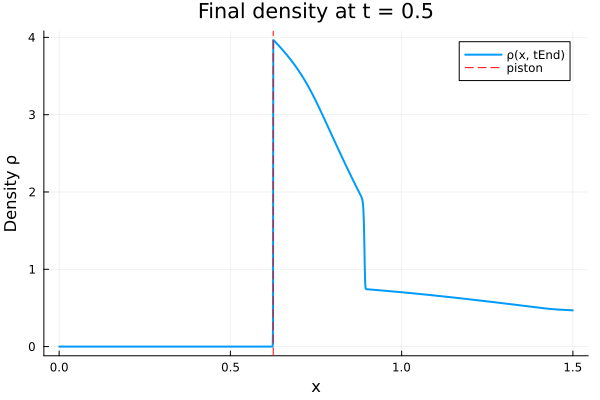

In [8]:
# --------------------Plot final density--------------------

density_plot = plot(
    x,
    ρ;
    lw=2,
    xlabel="x",
    ylabel="Density ρ",
    title="Final density at t = $(round(t, digits=4))",
    label="ρ(x, tEnd)",
)

if xpFinal !== nothing
    vline!(density_plot, [xpFinal]; color=:red, linestyle=:dash, label="piston")
end

display(density_plot)

# Optional: save figure
# savefig(density_plot, "final-density.png")


In [9]:
println("tShock = ", tShock)
println("xShock = ", xShock)

tShock = 0.1936491673103708
xShock = 0.24999999999999994


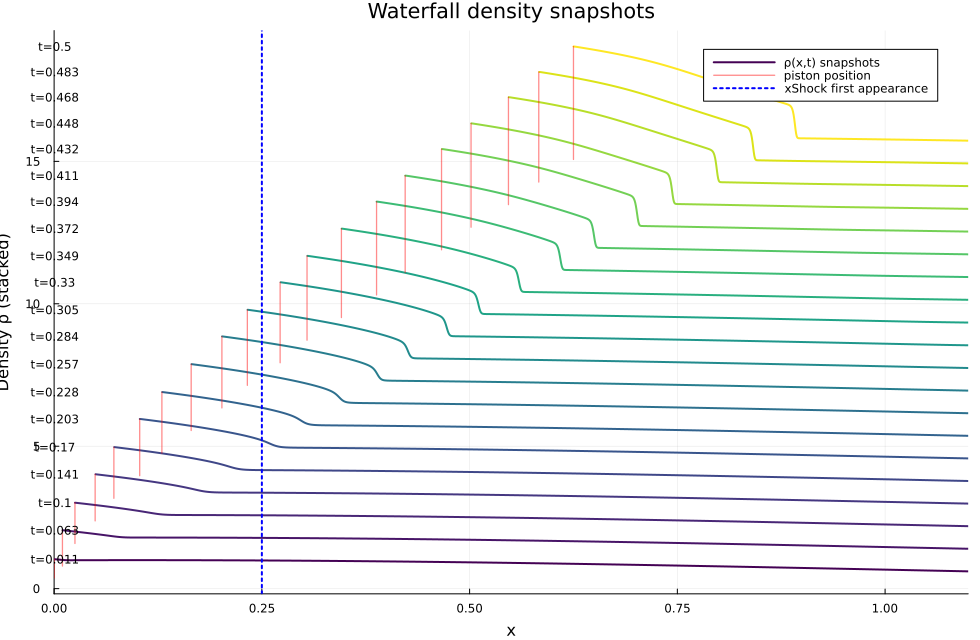

In [10]:

# --------------------Waterfall plot (density snapshots over time)--------------------
times_all = sort(collect(keys(history)))
if isempty(times_all) || times_all[end] != tEnd
    history[tEnd] = Ufinal
    times_all = sort(collect(keys(history)))
end
n_show = min(20, length(times_all))
idx = unique(round.(Int, range(1, length(times_all), length=n_show)))
times = times_all[idx]

rho_snaps = Vector{Vector{Float64}}(undef, length(times))
for (k, tk) in enumerate(times)
    Uk = history[tk]
    rho_snaps[k] = [prim(Uk[i])[1] for i in 1:nx]
end

rho_min = minimum(reduce(vcat, rho_snaps))
rho_max = maximum(reduce(vcat, rho_snaps))
rho_span = max(rho_max - rho_min, 1e-12)
y_offset = 0.20 * rho_span

waterfall_plot = plot(
    xlabel="x",
    ylabel="Density ρ (stacked)",
    title="Waterfall density snapshots",
    legend=:topright,
    size=(980, 640),
    xlim=(0, 1.1),
)

colors = palette(:viridis, length(times))

for (k, tk) in enumerate(times)
    y0 = (k - 1) * y_offset
    rho_k = rho_snaps[k]

    # Filter to show curve where x >= xpiston(tk)
    xp = xpiston(tk)
    valid_idx = findall(xi -> xi >= xp, x)
    x_plot = x[valid_idx]
    rho_plot = rho_k[valid_idx] .+ y0

    line_label = (k == 1) ? "ρ(x,t) snapshots" : ""
    plot!(
        waterfall_plot,
        x_plot,
        rho_plot;
        lw=2,
        color=colors[k],
        label=line_label,
    )

    annotate!(
        waterfall_plot,
        x[1],
        maximum(rho_k) + y0,
        text("t=$(round(tk, digits=3))", 8),
    )

    xp = xpiston(tk)
    piston_label = (k == 1) ? "piston position" : ""
    plot!(
        waterfall_plot,
        [xp, xp],
        [minimum(rho_k) + y0, maximum(rho_k) + y0];
        color=:red,
        alpha=0.45,
        lw=1.3,
        label=piston_label,
    )
end

# Add vertical line at shock location
vline!(
    waterfall_plot,
    [xShock],
    linestyle=:dot,
    color=:blue,
    lw=2,
    label="xShock first appearance"
)

display(waterfall_plot)

# Optional: save waterfall figure
# savefig(waterfall_plot, "density-waterfall.png")


In [11]:
# --------------------Export snapshots to CSV--------------------
# Exports long-format data: time, x, density, velocity, pressure
# and includes scalar setup parameters as additional CSV columns.
using CSV, DataFrames

times_out = sort(collect(keys(history)))
if isempty(times_out) || times_out[end] != tEnd
    history[tEnd] = U
    times_out = sort(collect(keys(history)))
end

rows = Vector{NamedTuple{(:time, :x, :density, :velocity, :pressure), NTuple{5, Float64}}}()
sizehint!(rows, length(times_out) * nx)

for tk in times_out
    Uk = history[tk]
    for i in 1:nx
        rho_i, u_i, p_i = prim(Uk[i])
        push!(rows, (time=Float64(tk), x=Float64(x[i]), density=rho_i, velocity=u_i, pressure=p_i))
    end
end

df_export = DataFrame(rows)

params = Dict{String, Any}(
    "gamma" => gamma,
    "xL" => xL,
    "xR" => xR,
    "nx" => nx,
    "dx" => dx,
    "xc" => xc,
    "CFL" => CFL,
    "CFLvisc" => CFLvisc,
    "CFLforce" => CFLforce,
    "tEnd" => tEnd,
    "a00" => a00,
    "gg" => gg,
    "temp" => temp,
    "ReynoldsNumber" => ReynoldsNumber,
    "c0" => c0,
    "mach" => mach,
    "pressureScale" => pressureScale,
    "tShock" => tShock,
    "a00_tShock" => a00_tShock,
    "xShock" => xShock
)

for (k, v) in params
    df_export[!, Symbol(k)] = fill(v, nrow(df_export))
end

re_str = replace(string(ReynoldsNumber), "." => "p")
csv_name = "moving_piston_no_left_gas_Re$(re_str).csv"
CSV.write(csv_name, df_export)
println("Exported CSV: ", csv_name, " (rows=", nrow(df_export), ", cols=", ncol(df_export), ")")


Exported CSV: moving_piston_no_left_gas_Re5000.csv (rows=176000, cols=25)
